In [65]:
import numpy as np

def geolin_matrix(s: str, n: int):
    s = s.replace('−', '-').replace('\u200b', '').split()
    d = np.zeros((n, len(s) // n))
    for i in range(len(s)):
        d[i % n][i // n] = s[i]
    return np.matrix(d)

def geolin_vector(s: str):
    s = s.replace('−', '-').replace('\u200b', '').split()
    return np.array([int(x) for x in s])

def geo(m: np.matrix):
    if m.shape[0] == 1:
        return f'[{', '.join([str(round(m.item(0, i), 10)) for i in range(m.shape[1])])}]'
    return f'[{'; '.join([', '.join([str(round(m.item(j, i), 10)) for i in range(m.shape[1])]) for j in range(m.shape[0])])}]'    

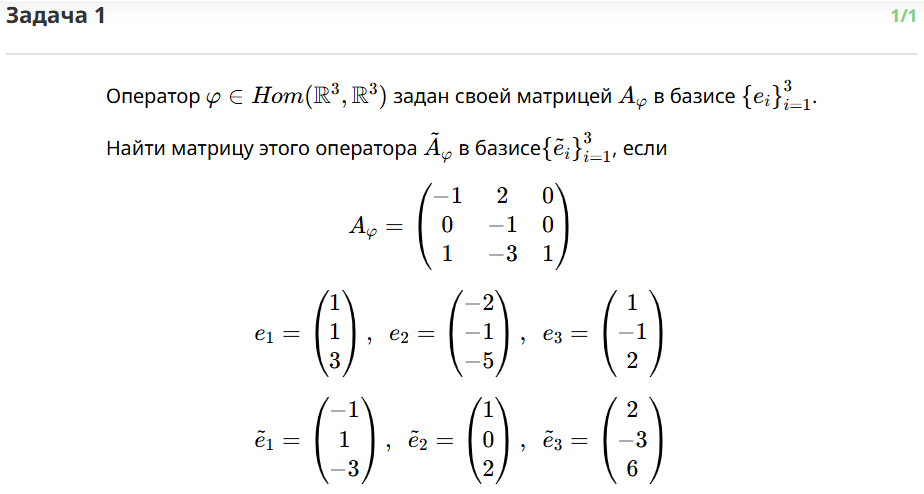

In [66]:
A = np.matrix([[-1, 2, 0], [0, -1, 0], [1, -3, 1]])
E_old = np.matrix([[1, 1, 3], [-2, -1, -5], [1, -1, 2]]).transpose()
E_new = np.matrix([[-1, 1, -3], [1, 0, 2], [2, -3, 6]]).transpose()

T = np.linalg.inv(E_old) @ E_new
print('Матрица перехода T = (old_e -> new_e)')
print(T.round(12))

A_new = np.linalg.inv(T) @ A @ T
print('Матрица в новом базисе inv(T) * A * T')
print(A_new)

print(geo(A_new))


Матрица перехода T = (old_e -> new_e)
[[-3. -1.  7.]
 [-2. -1.  5.]
 [-2.  0.  5.]]
Матрица в новом базисе inv(T) * A * T
[[ 17.  14. -46.]
 [ -1.   1.   2.]
 [  7.   6. -19.]]
[17.0, 14.0, -46.0; -1.0, 1.0, 2.0; 7.0, 6.0, -19.0]


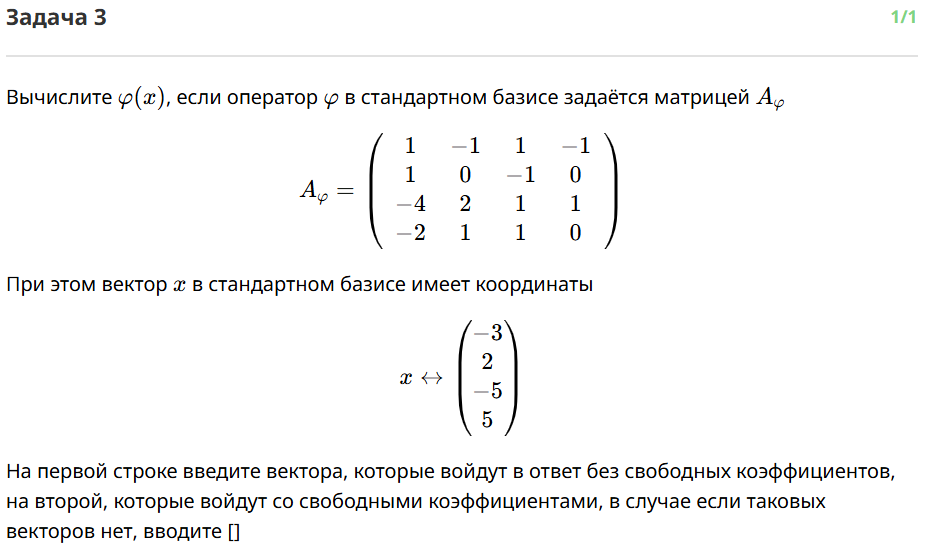

In [67]:
A = geolin_matrix('1 1 −4 −2 ​ −1 0 2 1 ​ 1 −1 1 1 ​ −1 0 1 0 ​ ​ ​', 4)
x = geolin_vector('−3 2 −5 5 ​ ​ ​')
print('Матрица оператора A:')
print(A)
print('Вектор x:')
print(x)

X = A @ x
print('Образ ф(x)')
print(X)

print('Ответ (свободные, базисные):')
print(geo(X))
print('[]')

Матрица оператора A:
[[ 1. -1.  1. -1.]
 [ 1.  0. -1.  0.]
 [-4.  2.  1.  1.]
 [-2.  1.  1.  0.]]
Вектор x:
[-3  2 -5  5]
Образ ф(x)
[[-15.   2.  16.   3.]]
Ответ (свободные, базисные):
[-15.0, 2.0, 16.0, 3.0]
[]


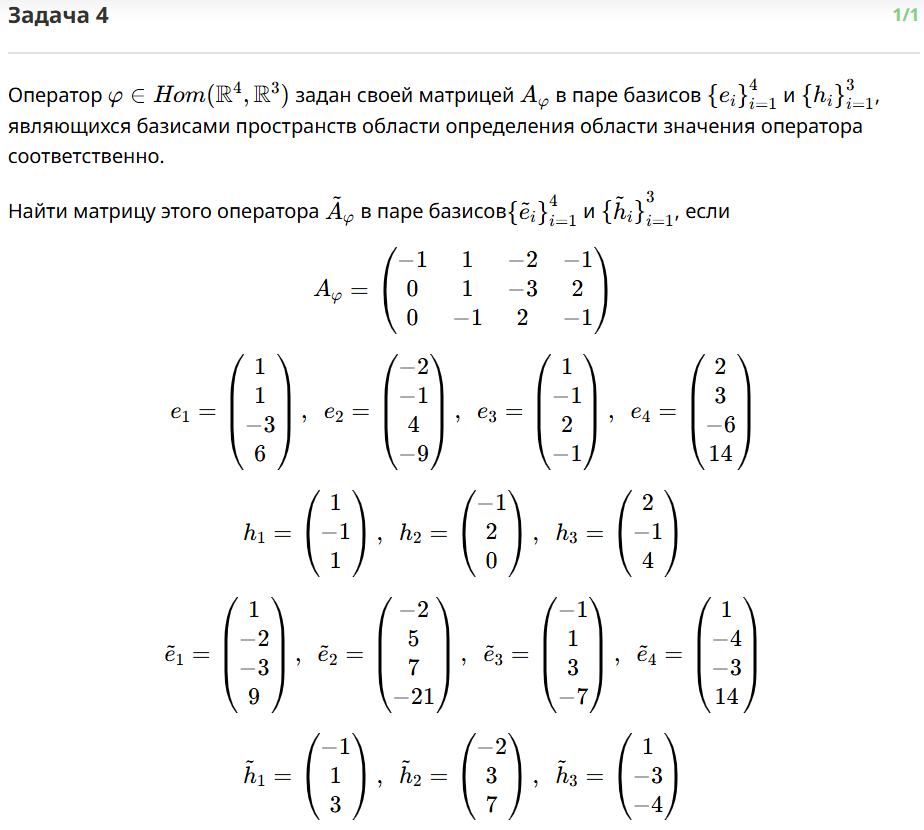

In [68]:
A = geolin_matrix('−1 0 0 ​ 1 1 −1 ​ −2 −3 2 ​ −1 2 −1 ​ ​ ​', 3)
E_old = np.matrix([
    [1, 1, -3, 6],
    [-2, -1, 4, -9],
    [1, -1, 2, -1],
    [2, 3, -6, 14]
]).transpose()
H_old = np.matrix([
    [1, -1, 1],
    [-1, 2, 0],
    [2, -1, 4]
]).transpose()
E_new = np.matrix([
    [1, -2, -3, 9],
    [-2, 5, 7, -21],
    [-1, 1, 3, -7],
    [1, -4, -3, 14]
]).transpose()
H_new = np.matrix([
    [-1, 1, 3],
    [-2, 3, 7],
    [1, -3, -4]
]).transpose()

print('Входные матрицы Аф, E_old, H_old, E_new, H_new')
# print(A, E_old, H_old, E_new, H_new, sep='\n')

print('Матрица перехода T = (E_old->E_new)')
T = np.linalg.inv(E_old) @ E_new
print(T)
print('Матрица перехода S^-1 = (H_new->H_old)')
inv_S = np.linalg.inv(H_new) @ H_old
print(inv_S)

print('Матрица Aф в новом базисе:')
res_A = inv_S @ A @ T
print(res_A)

print(geo(res_A))

Входные матрицы Аф, E_old, H_old, E_new, H_new
Матрица перехода T = (E_old->E_new)
[[ -83.  207.   45. -169.]
 [ -45.  112.   25.  -90.]
 [ -18.   45.   10.  -36.]
 [   6.  -15.   -3.   13.]]
Матрица перехода S^-1 = (H_new->H_old)
[[-13.  11. -31.]
 [  8.  -7.  19.]
 [  4.  -4.   9.]]
Матрица Aф в новом базисе:
[[ -746.  1844.   422. -1465.]
 [  454. -1122.  -257.   891.]
 [  215.  -531.  -122.   421.]]
[-746.0, 1844.0, 422.0, -1465.0; 454.0, -1122.0, -257.0, 891.0; 215.0, -531.0, -122.0, 421.0]


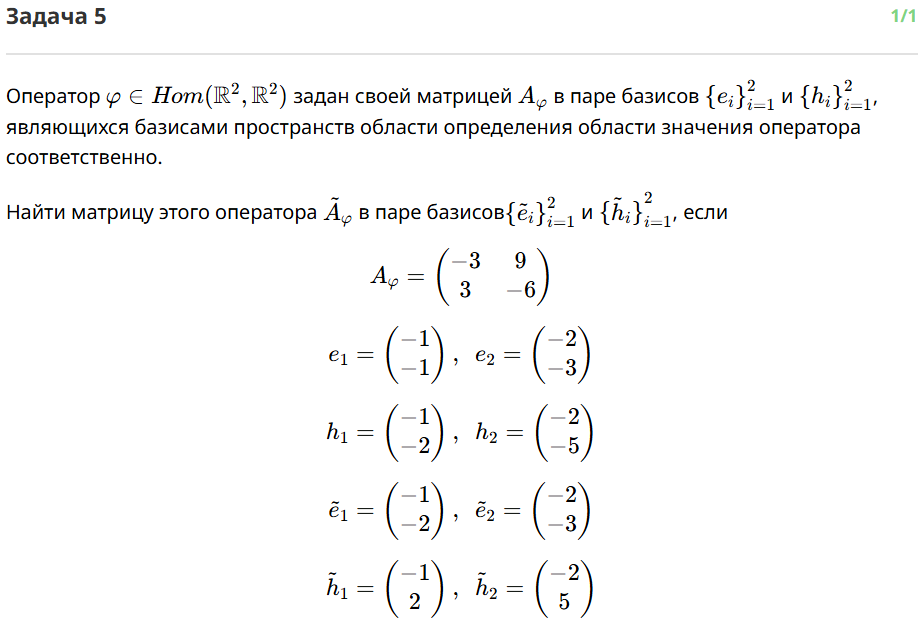

In [69]:
A = geolin_matrix('−3 3 ​ 9 −6​', 2)
E_old = np.matrix([
    [-1, -1],
    [-2, -3]
]).transpose()
H_old = np.matrix([
    [-1, -2],
    [-2, -5]
]).transpose()
E_new = np.matrix([
    [-1, -2],
    [-2, -3]
]).transpose()
H_new = np.matrix([
    [-1, 2],
    [-2, 5]
]).transpose()

print('Входные матрицы Аф, E_old, H_old, E_new, H_new')
# print(A, E_old, H_old, E_new, H_new, sep='\n')

print('Матрица перехода T = (E_old->E_new)')
T = np.linalg.inv(E_old) @ E_new
print(T)
print('Матрица перехода S^-1 = (H_new->H_old)')
inv_S = np.linalg.inv(H_new) @ H_old
print(inv_S)

print('Матрица Aф в новом базисе:')
res_A = inv_S @ A @ T
print(res_A)

print(geo(res_A))

Входные матрицы Аф, E_old, H_old, E_new, H_new
Матрица перехода T = (E_old->E_new)
[[-1.  0.]
 [ 1.  1.]]
Матрица перехода S^-1 = (H_new->H_old)
[[ 9. 20.]
 [-4. -9.]]
Матрица Aф в новом базисе:
[[-72. -39.]
 [ 33.  18.]]
[-72.0, -39.0; 33.0, 18.0]


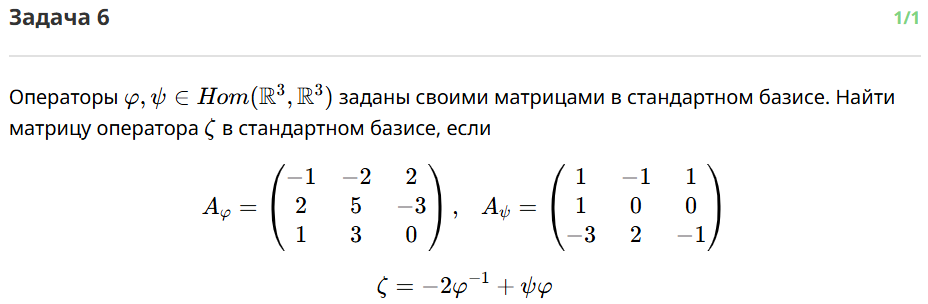

In [74]:
A1 = geolin_matrix('−1 2 1 ​ −2 5 3 ​ 2 −3 0', 3)
A2 = geolin_matrix('1 1 −3 ​ −1 0 2 ​ 1 0 −1 ', 3)

R = (-2)*np.linalg.inv(A1) + A2 @ A1
print(R)

print(geo(R))

[[ 16.   8.  -3.]
 [ -7.  -6.   4.]
 [  8.  15. -14.]]
[16.0, 8.0, -3.0; -7.0, -6.0, 4.0; 8.0, 15.0, -14.0]
